<a href="https://colab.research.google.com/github/tommihab/Haberstock-et-al.-2026-Supplementary-Material/blob/main/Haberstock_Ems_LSTM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Third part of the notebook series: LSTM model development for discharge forecasting of the Ems River

In [ ]:
# Import Packages
import numpy as np
import pandas as pd
import os
import tensorflow as tf
import random

In [ ]:
# SEED

SEED = 100

# OS-level determinism
os.environ["PYTHONHASHSEED"] = "0"
os.environ["TF_DETERMINISTIC_OPS"] = "1"
os.environ["TF_CUDNN_DETERMINISTIC"] = "1"

# less ‘random’ parallelism
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["TF_NUM_INTRAOP_THREADS"] = "1"
os.environ["TF_NUM_INTEROP_THREADS"] = "1"

# Seeds for relevant libraries

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Set TF to deterministic threads
tf.config.threading.set_intra_op_parallelism_threads(1)
tf.config.threading.set_inter_op_parallelism_threads(1)

print("Seeds set to:", SEED)

Seeds set to: 100


In [ ]:
# Determine the path of data

from pathlib import Path

REPO_URL = "https://github.com/tommihab/Haberstock-et-al.-2026-Supplementary-Material.git"
REPO_DIR = Path("/content/Ems-Discharge-Forecasting")

# Download the repository if it is not already available
if not REPO_DIR.exists():
    !git clone "{REPO_URL}" "{REPO_DIR}"

# File within the GitHub repository
file_path = REPO_DIR / "ML_Input_Data" / "Einen_Ems_Precipitation_Discharge_DOY.csv"

# Load csv file
df = pd.read_csv(file_path, sep=";")

print(df.shape)
print(df.head())

Cloning into '/content/Ems-Discharge-Forecasting'...
remote: Enumerating objects: 48, done.
remote: Counting objects: 100% (48/48), done.
remote: Compressing objects: 100% (46/46), done.
remote: Total 48 (delta 11), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (48/48), 15.65 MiB | 3.60 MiB/s, done.
Resolving deltas: 100% (11/11), done.
Updating files: 100% (26/26), done.
(149040, 11)
            MESS_DATUM  augustdorf_2007-2024.csv  \
0  2007-01-01 00:00:00                      0.24   
1  2007-01-01 01:00:00                      0.03   
2  2007-01-01 02:00:00                      0.00   
3  2007-01-01 03:00:00                      0.03   
4  2007-01-01 04:00:00                      1.90   

   bielefeld-mitte_2007-2024.csv  delbrueck-steinhorst_2007-2024.csv  \
0                            0.2                                0.25   
1                            0.0                                0.00   
2                            0.0                              

In [ ]:
# Parse & sort time column
df["MESS_DATUM"] = pd.to_datetime(df["MESS_DATUM"])
df = df.sort_values("MESS_DATUM").reset_index(drop=True)

# short overview
print("Shape:", df.shape)
print("Time range:", df["MESS_DATUM"].min(), "to", df["MESS_DATUM"].max())
print("\nColumns:")
print(df.columns.tolist())

# Check: exactly every hour & no duplicates
deltas = df["MESS_DATUM"].diff().dropna()
print("\nTime differences (Top):")
print(deltas.value_counts().head())

print("\nDuplicates in MESS_DATUM:", df["MESS_DATUM"].duplicated().any())
print("Missing Values (Top):")
print(df.isna().sum().sort_values(ascending=False).head(15))

# set index to time
df = df.set_index("MESS_DATUM")

# Define features
target_col = "discharge"
feature_cols = [c for c in df.columns if c != target_col]  # contains 7 stations + DOY_sin/DOY_cos

Shape: (149040, 11)
Time range: 2007-01-01 00:00:00 to 2024-01-01 23:00:00

Columns:
['MESS_DATUM', 'augustdorf_2007-2024.csv', 'bielefeld-mitte_2007-2024.csv', 'delbrueck-steinhorst_2007-2024.csv', 'rheda-wiedenbrueck_2007-2024.csv', 'rietberg_2007-2024.csv', 'Versmold-Vorbruch_2007-2025.csv', 'warendorf-freckenhorst_2007-2024.csv', 'discharge', 'DOY_sin', 'DOY_cos']

Time differences (Top):
MESS_DATUM
0 days 01:00:00    149039
Name: count, dtype: int64

Duplicates in MESS_DATUM: False
Missing Values (Top):
MESS_DATUM                              0
augustdorf_2007-2024.csv                0
bielefeld-mitte_2007-2024.csv           0
delbrueck-steinhorst_2007-2024.csv      0
rheda-wiedenbrueck_2007-2024.csv        0
rietberg_2007-2024.csv                  0
Versmold-Vorbruch_2007-2025.csv         0
warendorf-freckenhorst_2007-2024.csv    0
discharge                               0
DOY_sin                                 0
DOY_cos                                 0
dtype: int64


In [ ]:
# Create forecast horizons

horizons = [3, 6, 12, 24, 72]
target_col = "discharge"

df_targets = df.copy()  # df has time index MESS_DATUM

for h in horizons:
    df_targets[f"y_t+{h}"] = df_targets[target_col].shift(-h)

# Remove rows at the end that no longer have a target for the largest horizon
max_h = max(horizons)
df_targets = df_targets.iloc[:-max_h].copy()

print("Shape after target creation:", df_targets.shape)
print("Last Index Time:", df_targets.index.max())
print(df_targets[[target_col] + [f"y_t+{h}" for h in horizons]].tail(3))

Shape after target creation: (148968, 15)
Last Index Time: 2023-12-29 23:00:00
                     discharge  y_t+3  y_t+6  y_t+12  y_t+24  y_t+72
MESS_DATUM                                                          
2023-12-29 21:00:00      72.35  72.75  75.38   83.42   91.87   58.40
2023-12-29 22:00:00      72.37  73.41  76.75   84.70   91.55   58.40
2023-12-29 23:00:00      72.46  74.22  78.12   86.03   91.14   58.48


In [ ]:
target_col = "discharge"

# Features: all except drainage and Y-columns
exclude = {target_col}
exclude |= {f"y_t+{h}" for h in horizons}
feature_cols = [c for c in df_targets.columns if c not in exclude]

print("Number of Feature Columns:", len(feature_cols))
print("Feature Columns:", feature_cols)

# Split indices (temporal, without shuffle)
N = len(df_targets)
i_train_end = int(N * 0.60)
i_val_end   = int(N * 0.75)   # 70% train + 10% val

train_df = df_targets.iloc[:i_train_end].copy()
val_df   = df_targets.iloc[i_train_end:i_val_end].copy()
test_df  = df_targets.iloc[i_val_end:].copy()

print("\nSplit sizes:", len(train_df), len(val_df), len(test_df))
print("Train:", train_df.index.min(), "→", train_df.index.max())
print("Val:  ", val_df.index.min(),   "→", val_df.index.max())
print("Test: ", test_df.index.min(),  "→", test_df.index.max())

Number of Feature Columns: 9
Feature Columns: ['augustdorf_2007-2024.csv', 'bielefeld-mitte_2007-2024.csv', 'delbrueck-steinhorst_2007-2024.csv', 'rheda-wiedenbrueck_2007-2024.csv', 'rietberg_2007-2024.csv', 'Versmold-Vorbruch_2007-2025.csv', 'warendorf-freckenhorst_2007-2024.csv', 'DOY_sin', 'DOY_cos']

Split sizes: 89380 22346 37242
Train: 2007-01-01 00:00:00 → 2017-03-13 03:00:00
Val:   2017-03-13 04:00:00 → 2019-09-30 05:00:00
Test:  2019-09-30 06:00:00 → 2023-12-29 23:00:00


In [ ]:
# Identify precipitation columns from feature_cols (excluding DOY_sin and DOY_cos)
precipitation_cols = [c for c in feature_cols if not (c.startswith('DOY_sin') or c.startswith('DOY_cos'))]

def add_p_mean(df_):
    df_ = df_.copy()
    if "P_mean" not in df_.columns:
        df_["P_mean"] = df_[precipitation_cols].mean(axis=1)
    return df_

train_df2 = add_p_mean(train_df)
val_df2   = add_p_mean(val_df)
test_df2  = add_p_mean(test_df)

# Leave out DOY and focus on P_mean and discharge
cols_to_check = ["P_mean", target_col]  # target_col is 'discharge'

def stats_block(df_, cols):
    s = df_[cols].describe().loc[["mean", "std", "min", "max"]]
    return s

stats_train = stats_block(train_df2, cols_to_check)
stats_val   = stats_block(val_df2, cols_to_check)
stats_test  = stats_block(test_df2, cols_to_check)

print("\nTraining Data Stats:\n", stats_train, "\n")
print("Validation Data Stats:\n", stats_val, "\n")
print("Testing Data Stats:\n", stats_test, "\n")

# comparison in table
stats_all = pd.concat(
    {"train": stats_train, "val": stats_val, "test": stats_test},
    axis=0
)


Training Data Stats:
          P_mean   discharge
mean   0.089830   13.833615
std    0.346695   12.590450
min    0.000000    0.700000
max   12.657143  120.210000 

Validation Data Stats:
         P_mean  discharge
mean  0.080123  11.479265
std   0.306614  12.516851
min   0.000000   0.780000
max   6.965714  92.380000 

Testing Data Stats:
          P_mean   discharge
mean   0.093841   12.260344
std    0.369315   13.597653
min    0.000000    0.670000
max   14.092857  154.120000 



In [ ]:
from sklearn.preprocessing import MinMaxScaler

# Scale all numerical Inputs + discharge + DOY, but no y_t+ columns
horizons = [3, 6, 12, 24, 72]
target_cols = [f"y_t+{h}" for h in horizons]

# Feature columns: all except targets (y_...) (discharge + stations + DOY remain)
scale_cols = [c for c in df_targets.columns if c not in target_cols]

# Safety: if the time index exists again as a column, remove it
scale_cols = [c for c in scale_cols if c != "MESS_DATUM"]

print("Scaling Columns (Count):", len(scale_cols))
print(scale_cols)

# Fit scaler on Train data
scaler = MinMaxScaler()
scaler.fit(train_df[scale_cols])

# Transform (keep copy)
train_scaled = train_df.copy()
val_scaled   = val_df.copy()
test_scaled  = test_df.copy()

train_scaled[scale_cols] = scaler.transform(train_df[scale_cols])
val_scaled[scale_cols]   = scaler.transform(val_df[scale_cols])
test_scaled[scale_cols]  = scaler.transform(test_df[scale_cols])

# Quick checks
def minmax_check(df_, cols, name):
    mins = df_[cols].min().min()
    maxs = df_[cols].max().max()
    print(f"{name}: global min={mins:.4f}, global max={maxs:.4f}")

minmax_check(train_scaled, scale_cols, "Train scaled")
minmax_check(val_scaled, scale_cols, "Val scaled")
minmax_check(test_scaled, scale_cols, "Test scaled")

# check if Val/Test go out of 0,1
out_of_bounds_val = ((val_scaled[scale_cols] < 0) | (val_scaled[scale_cols] > 1)).sum().sum()
out_of_bounds_test = ((test_scaled[scale_cols] < 0) | (test_scaled[scale_cols] > 1)).sum().sum()
print("Val out-of-bounds count:", int(out_of_bounds_val))
print("Test out-of-bounds count:", int(out_of_bounds_test))

Scaling Columns (Count): 10
['augustdorf_2007-2024.csv', 'bielefeld-mitte_2007-2024.csv', 'delbrueck-steinhorst_2007-2024.csv', 'rheda-wiedenbrueck_2007-2024.csv', 'rietberg_2007-2024.csv', 'Versmold-Vorbruch_2007-2025.csv', 'warendorf-freckenhorst_2007-2024.csv', 'discharge', 'DOY_sin', 'DOY_cos']
Train scaled: global min=0.0000, global max=1.0000
Val scaled: global min=0.0000, global max=1.0000
Test scaled: global min=-0.0003, global max=2.1716
Val out-of-bounds count: 0
Test out-of-bounds count: 95


In [ ]:
lookback = 96 # Number of previous time steps for the model's prediction

# Input features (X) for the model, including scaled precipitation, discharge, and DOY features.
x_cols = scale_cols # Columns from the MinMaxScaler
assert "discharge" in x_cols, "'discharge' must be an input feature!"

# Scale Target Variables (y_t+H)
# Targets are scaled consistently using the same min/max as the 'discharge' input.

# Get min/max from 'discharge' in training data for scaling targets.
discharge_idx = x_cols.index("discharge")
ab_min = scaler.data_min_[discharge_idx]
ab_max = scaler.data_max_[discharge_idx]
ab_range = (ab_max - ab_min) if (ab_max - ab_min) != 0 else 1.0 # Avoid division by zero

def scale_like_discharge(y):
    """Scales an array/series `y` using 'discharge' min/max from training data."""
    return (y - ab_min) / ab_range

# Apply this scaling to all forecast horizons for train, val, and test datasets.
for h in horizons:
    ycol = f"y_t+{h}"
    train_scaled[f"{ycol}_scaled"] = scale_like_discharge(train_scaled[ycol].values)
    val_scaled[f"{ycol}_scaled"]   = scale_like_discharge(val_scaled[ycol].values)
    test_scaled[f"{ycol}_scaled"]  = scale_like_discharge(test_scaled[ycol].values)

print(f"Discharge Min/Max used for scaling (from training data): {ab_min} / {ab_max}")


# Helper Function: Build Time Series Sequences with Context
# This creates X (input sequences) and y (target values) for training, validation,
# and testing, handling context from previous data splits for val/test sets.

def make_sequences_with_context(context_df, current_split_df, x_features, y_target_scaled_col, sequence_length):
    """
    Generates time series sequences (X) and corresponding targets (y).
    """

    if context_df is None:
        # For training data, just use the current split.
        combined_data = current_split_df.copy()
        first_valid_idx_for_target = sequence_length - 1
        if len(combined_data) < sequence_length:
            raise ValueError("Not enough data to create sequences with the given lookback length.")
        valid_target_indices = range(first_valid_idx_for_target, len(combined_data))
        offset_for_current_data = 0
    else:
        # For val/test, concatenate context from previous split.
        combined_data = pd.concat([context_df, current_split_df], axis=0)
        first_valid_idx_for_target = sequence_length - 1
        # Targets only belong to current_split_df, so calculate offset.
        offset_for_current_data = len(context_df)
        valid_target_indices = range(offset_for_current_data + (sequence_length - 1), len(combined_data))

    X_sequences, y_targets, target_timestamps = [], [], []

    # Convert to NumPy for faster processing
    X_all_data = combined_data[x_features].to_numpy(dtype=np.float32)
    y_all_data = combined_data[y_target_scaled_col].to_numpy(dtype=np.float32)

    # Iterate to create sequences
    for t_idx in valid_target_indices:
        x_start_idx = t_idx - (sequence_length - 1)
        x_end_idx = t_idx + 1

        X_sequences.append(X_all_data[x_start_idx:x_end_idx, :])
        y_targets.append(y_all_data[t_idx])
        target_timestamps.append(combined_data.index[t_idx])

    # Stack results into NumPy arrays
    X_result = np.stack(X_sequences).astype(np.float32)
    y_result = np.array(y_targets, dtype=np.float32)
    times_result = pd.Index(target_timestamps)

    return X_result, y_result, times_result


# Generate Datasets for Each Forecast Horizon
# Create training, validation, and test datasets (X, y, timestamps) for each horizon.

datasets = {}

for h in horizons:
    y_col_for_current_horizon = f"y_t+{h}_scaled"

    print(f"\nProcessing Horizon {h}h...")

    # Training Data: No context needed.
    X_train, y_train, t_train = make_sequences_with_context(
        context_df=None,
        current_split_df=train_scaled,
        x_features=x_cols,
        y_target_scaled_col=y_col_for_current_horizon,
        sequence_length=lookback
    )

    # Validation Data: Context from end of training data.
    X_val, y_val, t_val = make_sequences_with_context(
        context_df=train_scaled.tail(lookback),
        current_split_df=val_scaled,
        x_features=x_cols,
        y_target_scaled_col=y_col_for_current_horizon,
        sequence_length=lookback
    )

    # Test Data: Context from end of validation data.
    X_test, y_test, t_test = make_sequences_with_context(
        context_df=val_scaled.tail(lookback),
        current_split_df=test_scaled,
        x_features=x_cols,
        y_target_scaled_col=y_col_for_current_horizon,
        sequence_length=lookback
    )

    # Store all datasets for this horizon
    datasets[h] = {
        "X_train": X_train, "y_train": y_train, "t_train": t_train,
        "X_val": X_val, "y_val": y_val, "t_val": t_val,
        "X_test": X_test, "y_test": y_test, "t_test": t_test,
    }

    # Print shapes for confirmation
    print(f"  Horizon {h}h Data Shapes:")
    print(f"    X_train: {X_train.shape}, y_train: {y_train.shape}")
    print(f"    X_val:   {X_val.shape}, y_val:   {y_val.shape}")
    print(f"    X_test:  {X_test.shape}, y_test:  {y_test.shape}")

# Quick check on number of features per timestep
print(f"\nTotal features per timestep in X sequences: {datasets[horizons[0]]["X_train"].shape[-1]} -> ({', '.join(x_cols)})")

Discharge Min/Max used for scaling (from training data): 0.7 / 120.21

Processing Horizon 3h...
  Horizon 3h Data Shapes:
    X_train: (89285, 96, 10), y_train: (89285,)
    X_val:   (22251, 96, 10), y_val:   (22251,)
    X_test:  (37147, 96, 10), y_test:  (37147,)

Processing Horizon 6h...
  Horizon 6h Data Shapes:
    X_train: (89285, 96, 10), y_train: (89285,)
    X_val:   (22251, 96, 10), y_val:   (22251,)
    X_test:  (37147, 96, 10), y_test:  (37147,)

Processing Horizon 12h...
  Horizon 12h Data Shapes:
    X_train: (89285, 96, 10), y_train: (89285,)
    X_val:   (22251, 96, 10), y_val:   (22251,)
    X_test:  (37147, 96, 10), y_test:  (37147,)

Processing Horizon 24h...
  Horizon 24h Data Shapes:
    X_train: (89285, 96, 10), y_train: (89285,)
    X_val:   (22251, 96, 10), y_val:   (22251,)
    X_test:  (37147, 96, 10), y_test:  (37147,)

Processing Horizon 72h...
  Horizon 72h Data Shapes:
    X_train: (89285, 96, 10), y_train: (89285,)
    X_val:   (22251, 96, 10), y_val:   (

In [ ]:
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Input, LSTM, Dropout, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import Huber, mse
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

# Settings
n_timesteps = lookback
n_features = len(x_cols)


In [ ]:
# Build an LSTM model for time series forecasting

def build_lstm_model(n_timesteps, n_features, lr=0.001):
    model = Sequential([
        Input(shape=(n_timesteps, n_features)),
        LSTM(128, return_sequences=True),
        Dropout(0.1),
        LSTM(64, return_sequences=False),
        Dropout(0.1),
        Dense(16, activation="relu"),
        Dense(1)
    ])
    model.compile(
        optimizer=Adam(learning_rate=lr),
        loss=mse,
        metrics=[tf.keras.metrics.MAE]
    )
    model.summary()
    return model

In [ ]:
# Folder for models
os.makedirs("models", exist_ok=True)

histories = {}
models = {}
test_metrics = {}


In [ ]:
# INFO: running this Code cell will start running the LSTM model. This will take several hours.
# In order to save time please jump to the code cell below and load the five trained models.

for h in horizons:
    data = datasets[h]
    X_train, y_train = data["X_train"], data["y_train"]
    X_val, y_val     = data["X_val"], data["y_val"]
    X_test, y_test   = data["X_test"], data["y_test"]

    # Keras often expects (n,1) for y; both work, but this is cleaner
    y_train_ = y_train.reshape(-1, 1)
    y_val_   = y_val.reshape(-1, 1)
    y_test_  = y_test.reshape(-1, 1)

    model = build_lstm_model(n_timesteps, n_features, lr=1e-3)

    callbacks = [
        EarlyStopping(monitor="val_loss", patience=12, restore_best_weights=True),
        ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=4, min_lr=1e-6, verbose=1),
        ModelCheckpoint(
            filepath=f"models/lstm_h{h}.keras",
            monitor="val_loss",
            save_best_only=True,
            verbose=1
        )
    ]

    print(f"\n===== Training Horizon {h}h =====")
    history = model.fit(
        X_train, y_train_,
        validation_data=(X_val, y_val_),
        epochs=50,
        batch_size=64,
        shuffle=False,
        verbose=1,
        callbacks=callbacks
    )

    # Evaluation (on scaled y)
    loss, mae = model.evaluate(X_test, y_test_, verbose=0)
    print(f"Horizon {h}h | Test (scaled) -> loss={loss:.4f}, MAE={mae:.4f}")

    histories[h] = history.history
    models[h] = model
    test_metrics[h] = {"loss_scaled": float(loss), "mae_scaled": float(mae)}


In [ ]:
# Load the models for all forecast horizons
models_dir = REPO_DIR / "trained_lstm_models"

loaded_models = {}

print(f"Loading models from: {models_dir}")

for h in horizons:
    model_path = models_dir / f"lstm_h{h}.keras"

    if model_path.exists():
        try:
            loaded_models[h] = tf.keras.models.load_model(model_path)
            print(f"Successfully loaded model for Horizon {h}h")

        except Exception as e:
            print(f"Error loading model for Horizon {h}h: {e}")

    else:
        print(f"Model file not found for Horizon {h}h: {model_path}")

print("\nAll loaded models:", loaded_models.keys())

Loading models from: /content/Ems-Discharge-Forecasting/trained_lstm_models
Successfully loaded model for Horizon 3h
Successfully loaded model for Horizon 6h
Successfully loaded model for Horizon 12h
Successfully loaded model for Horizon 24h
Successfully loaded model for Horizon 72h

All loaded models: dict_keys([3, 6, 12, 24, 72])


In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Make sure inverse_scale_abfluss is defined (from previous cells)
def inverse_scale_abfluss(y_scaled):
    y_scaled = np.asarray(y_scaled).reshape(-1)
    return y_scaled * ab_range + ab_min

# Make sure nse, kge, clean_xy are defined (from previous cells)
def nse(y_true, y_pred):
    y_true = np.asarray(y_true).reshape(-1)
    y_pred = np.asarray(y_pred).reshape(-1)
    denom = np.sum((y_true - np.mean(y_true))**2)
    return 1.0 - (np.sum((y_pred - y_true)**2) / denom) if denom != 0 else np.nan

def kge(y_true, y_pred):
    y_true = np.asarray(y_true).reshape(-1)
    y_pred = np.asarray(y_pred).reshape(-1)

    if np.std(y_true) == 0 or np.std(y_pred) == 0:
        r = np.nan
    else:
        r = np.corrcoef(y_true, y_pred)[0, 1]

    std_obs = np.std(y_true, ddof=0)
    std_sim = np.std(y_pred, ddof=0)
    mean_obs = np.mean(y_true)
    mean_sim = np.mean(y_pred)

    alpha = (std_sim / std_obs) if std_obs != 0 else np.nan
    beta  = (mean_sim / mean_obs) if mean_obs != 0 else np.nan

    return 1.0 - np.sqrt((r - 1.0)**2 + (alpha - 1.0)**2 + (beta - 1.0)**2)

def clean_xy(y_true, y_pred):
    y_true = np.asarray(y_true).reshape(-1)
    y_pred = np.asarray(y_pred).reshape(-1)
    m = np.isfinite(y_true) & np.isfinite(y_pred)
    return y_true[m], y_pred[m]


predictions_loaded_models = {} # Use a new dictionary for clarity
rows = []

print("Calculating metrics using loaded models...")

for h in horizons:
    if h not in datasets: # Ensure datasets for the horizon are available
        print(f"Warning: Dataset for Horizon {h}h not found. Skipping.")
        continue
    if h not in loaded_models: # Ensure loaded model for the horizon is available
        print(f"Warning: Model for Horizon {h}h not found in loaded_models. Skipping.")
        continue

    X_test = datasets[h]["X_test"]
    y_test_scaled = datasets[h]["y_test"]
    t_test = datasets[h]["t_test"]

    # Get predictions from the loaded model
    y_pred_scaled = loaded_models[h].predict(X_test, verbose=1).reshape(-1)

    # Inverse scale predictions and true values
    y_true = inverse_scale_abfluss(y_test_scaled)
    y_pred = inverse_scale_abfluss(y_pred_scaled)

    predictions_loaded_models[h] = {
        "t_test": t_test,
        "y_true": y_true,
        "y_pred": y_pred,
        "y_true_scaled": y_test_scaled,
        "y_pred_scaled": y_pred_scaled,
    }

    # Calculate metrics
    y_true_clean, y_pred_clean = clean_xy(y_true, y_pred)

    rmse = np.sqrt(mean_squared_error(y_true_clean, y_pred_clean))
    mae  = mean_absolute_error(y_true_clean, y_pred_clean)
    # R2 from sklearn.metrics.r2_score is more robust for general cases
    r2   = np.corrcoef(y_true_clean, y_pred_clean)[0, 1] # Pearson r as requested previously
    NSE_val  = nse(y_true_clean, y_pred_clean)
    KGE_val  = kge(y_true_clean, y_pred_clean)

    rows.append({
        "Horizon_h": h,
        "RMSE": rmse,
        "MAE": mae,
        "R2": r2,
        "NSE": NSE_val,
        "KGE": KGE_val,
        "n_test": len(y_true_clean)
    })

metrics_table_loaded_models = pd.DataFrame(rows).sort_values("Horizon_h").reset_index(drop=True)

# Display the metrics table
print("\nMetrics for Loaded Models:")
display(metrics_table_loaded_models.round(4))


Calculating metrics using loaded models...
1161/1161 ━━━━━━━━━━━━━━━━━━━━ 45s 39ms/step
1161/1161 ━━━━━━━━━━━━━━━━━━━━ 44s 38ms/step
1161/1161 ━━━━━━━━━━━━━━━━━━━━ 44s 38ms/step
1161/1161 ━━━━━━━━━━━━━━━━━━━━ 44s 38ms/step
1161/1161 ━━━━━━━━━━━━━━━━━━━━ 45s 39ms/step

Metrics for Loaded Models:


,Horizon_h,RMSE,MAE,R2,NSE,KGE,n_test
0,3,0.8506,0.4292,0.9982,0.9961,0.9795,37147
1,6,1.1905,0.6111,0.9962,0.9924,0.9889,37147
2,12,2.0803,1.0429,0.9885,0.9768,0.9666,37147
3,24,4.3071,1.9564,0.9519,0.9017,0.8763,37147
4,72,8.9330,4.1468,0.7759,0.5876,0.5891,37147


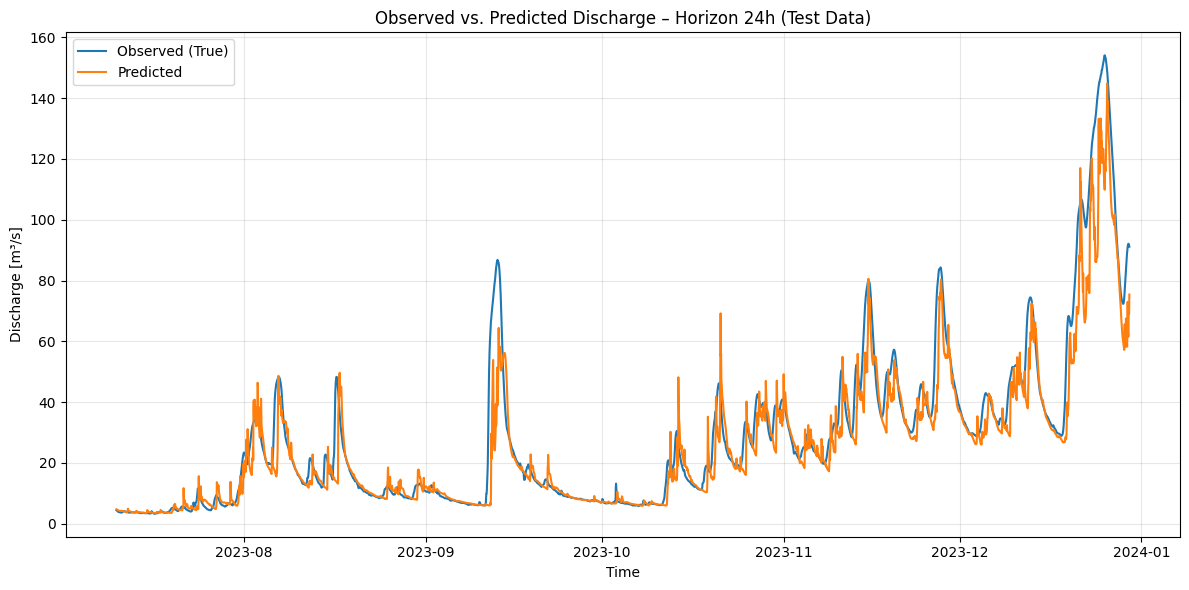

In [ ]:
# Plot the predicted values against the observed values

import matplotlib.pyplot as plt

def plot_test_slice_loaded_models(h, start=0, length=None):
    if h not in predictions_loaded_models:
        print(f"Error: No predictions found for Horizon {h}h.")
        return

    t = predictions_loaded_models[h]["t_test"]
    y_true = predictions_loaded_models[h]["y_true"]
    y_pred = predictions_loaded_models[h]["y_pred"]

    if length is None:
        end = len(t)
    else:
        end = min(start + length, len(t))

    plt.figure(figsize=(12, 6))
    plt.plot(t[start:end], y_true[start:end], label="Observed (True)")
    plt.plot(t[start:end], y_pred[start:end], label="Predicted")
    plt.title(f"Observed vs. Predicted Discharge – Horizon {h}h (Test Data)")
    plt.xlabel("Time")
    plt.ylabel("Discharge [m³/s]")
    plt.legend(loc = "upper left")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# Example
selected_horizon = 24  # Change this value to plot a different horizon (3, 12, 24, 72)
plot_test_slice_loaded_models(selected_horizon, start=33000, length=None) # Plotting the entire length

In [ ]:
# Create Scatterplott

import matplotlib.pyplot as plt

def plot_scatter_observed_predicted(horizon_list):
    fig = plt.figure(figsize=(15, 10))
    for i, h in enumerate(horizon_list):
        if h not in predictions_loaded_models:
            print(f"Error: No predictions found for Horizon {h}h. Skipping scatter plot.")
            continue

        y_true = predictions_loaded_models[h]["y_true"]
        y_pred = predictions_loaded_models[h]["y_pred"]

        # Clean data for plotting (remove NaNs if any)
        y_true_clean, y_pred_clean = clean_xy(y_true, y_pred)

        plt.subplot(2, 2, i + 1) # Create a 2x2 grid for subplots
        plt.scatter(y_true_clean, y_pred_clean, alpha=0.3, s=5, label=f'Predicted values')

        # Add a 1:1 line
        min_val = min(y_true_clean.min(), y_pred_clean.min())
        max_val = max(y_true_clean.max(), y_pred_clean.max())
        plt.plot([min_val, max_val], [min_val, max_val], 'r', label='Perfect agreement with observation')

        plt.title(f'Horizon {h}h', fontsize=12) # Smaller title for each subplot
        plt.grid(True, alpha=0.3)
        plt.legend()

    # Add shared x and y labels
    fig.supxlabel('Observed Discharge [m³/s]', fontsize=14)
    fig.supylabel('Predicted Discharge [m³/s]', fontsize=14)

    plt.tight_layout(rect=[0.03, 0.03, 1, 0.97]) # Adjust layout to make space for suptitle and supxlabel
    plt.suptitle('Observed vs. Predicted Discharge (Test Data)', fontsize=16, y=1.02) # Main title
    plt.show()

# List of horizons for which to create scatterplots (adjusted to 4 horizons for a 2x2 grid)
selected_horizons_for_scatter = [3, 6, 12, 24] # Change this to 72, to see the 72h horizon scatterplot
plot_scatter_observed_predicted(selected_horizons_for_scatter)

In [ ]:
# LSTM model peak sequence comparison

import matplotlib.dates as mdates
import matplotlib.ticker as mticker

def plot_test_slice_loaded_models(h, start=0, length=None):
    if h not in predictions_loaded_models:
        print(f"Error: No predictions found for Horizon {h}h.")
        return

    t = predictions_loaded_models[h]["t_test"]
    y_true = predictions_loaded_models[h]["y_true"]
    y_pred = predictions_loaded_models[h]["y_pred"]

    if length == None:
        end = len(t)
    else:
        end = min(start + length, len(t))

    # Get P_mean from test_df2 for the corresponding time slice
    p_mean_data = test_df2.loc[t[start:end], "P_mean"]

    fig, ax1 = plt.subplots(figsize=(7, 6))

    line1 = ax1.plot(t[start:end], y_true[start:end], label="Observed (True) Discharge")
    line2 = ax1.plot(t[start:end], y_pred[start:end], label="Predicted Discharge")
    ax1.set_xlabel("Time")
    ax1.set_ylabel("Discharge [m³/s]", color='black')
    ax1.tick_params(axis='y', labelcolor='black')

    # Set x-axis major and minor locators for consistent grid
    # Changed DayLocator interval to 5 days to reduce density
    ax1.xaxis.set_major_locator(mdates.DayLocator(interval=5)) # Major ticks every 5 days
    ax1.xaxis.set_minor_locator(mticker.NullLocator()) # Remove minor ticks
    ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))

    # Apply grid to ax1 (both x and y, and x will apply to ax2 implicitly)
    ax1.grid(True, alpha=0.7, linestyle='-') # Use higher alpha and solid linestyle
    ax1.set_axisbelow(True) # Ensure grid is behind the plotted data

    # Set discharge y-axis limits
    ax1.set_ylim(0, 200)

    # Create a secondary y-axis for P_weighted
    ax2 = ax1.twinx()
    line3 = ax2.plot(p_mean_data.index, p_mean_data, label='Precipitation [mm]', color='black', alpha=0.7)
    ax2.set_ylabel('Precipitation [mm]', color='black')
    ax2.tick_params(axis='y', labelcolor='black')
    ax2.invert_yaxis()

    ax2.yaxis.grid(True, alpha=0.7, linestyle='-')
    ax2.set_axisbelow(True)

    # Set P_weighted y-axis limits
    ax2.set_ylim(20, 0)

    # Combine legends from both axes
    lines = line1 + line2 + line3
    labels = [l.get_label() for l in lines]

    plt.legend(lines, labels, loc='center left', fontsize='small')

    plt.title(f"Observed vs. Predicted – Horizon {h}h (Test Data)")
    fig.tight_layout()
    fig.autofmt_xdate()
    plt.show()

selected_horizon = 24  # Change this value to plot a different horizon (e.g., 3, 12, 24, 72)
plot_test_slice_loaded_models(selected_horizon, start=34200, length=700) # adjust length / Change this to start = 36100, to see the other two peaks

In [ ]:
# Plot autocorrelation of LSTM model Residuals

from statsmodels.graphics.tsaplots import plot_acf

def analyze_residuals(h, y_true, y_pred):
    """
    Calculates and visualizes residuals and their Autocorrelation Function (ACF).
    """

    import matplotlib.pyplot as plt

    print(f"\n--- Analyzing Residuals for Horizon {h}h ---")

    # Clean data by removing NaNs
    y_true_clean, y_pred_clean = clean_xy(y_true, y_pred)

    # Skip if no valid data remains
    if len(y_true_clean) == 0:
        print(f"Warning: No valid data for Horizon {h}h after cleaning. Skipping residual analysis.")
        return

    # Calculate residuals
    residuals = y_true_clean - y_pred_clean

    # Plot ACF of Residuals
    fig, ax = plt.subplots(figsize=(10, 5))
    plot_acf(residuals, lags=72, ax=ax, title=f'ACF of Residuals - Horizon {h}h')
    plt.xlabel('Lags')
    plt.ylabel('Correlation')
    plt.grid(True, alpha=0.3)
    plt.show()

# Iterate through horizons and analyze residuals
for h in horizons:
    if h not in predictions_loaded_models:
        print(f"Warning: No predictions found for Horizon {h}h. Skipping residual analysis.")
        continue

    y_true = predictions_loaded_models[h]["y_true"]
    y_pred = predictions_loaded_models[h]["y_pred"]
    analyze_residuals(h, y_true, y_pred)

In [ ]:
def analyze_residuals_top_quantile(h, y_true, y_pred, quantile_threshold=0.95):
    """
    Analyzes residuals and their Autocorrelation Function (ACF) for top quantile of observed values.
    """
    import matplotlib.pyplot as plt

    print(f"\n--- Analyzing Residuals for Horizon {h}h (Top {int((1-quantile_threshold)*100)}% of Observed) ---")

    y_true_clean, y_pred_clean = clean_xy(y_true, y_pred)

    if len(y_true_clean) == 0:
        print(f"Warning: No valid data for Horizon {h}h after cleaning. Skipping residual analysis.")
        return

    # Determine threshold for top quantile
    threshold_value = np.percentile(y_true_clean, quantile_threshold * 100)

    # Filter values
    mask = y_true_clean >= threshold_value
    y_true_filtered = y_true_clean[mask]
    y_pred_filtered = y_pred_clean[mask]

    if len(y_true_filtered) == 0:
        print(f"Warning: No values in the top {int((1-quantile_threshold)*100)}% for Horizon {h}h. Skipping residual analysis.")
        return

    residuals = y_true_filtered - y_pred_filtered

    # Plot ACF of Residuals
    fig, ax = plt.subplots(figsize=(10, 5))
    plot_acf(residuals, lags=min(72, len(residuals) // 2 - 1), ax=ax, title=f'ACF of Residuals - Horizon {h}h (Top {int((1-quantile_threshold)*100)}% of Observed)')
    plt.xlabel('Lags')
    plt.ylabel('Correlation')
    plt.grid(True, alpha=0.3)
    plt.show()

for h in horizons:
    if h not in predictions_loaded_models:
        print(f"Warning: No predictions found for Horizon {h}h. Skipping residual analysis for top quantile.")
        continue

    y_true = predictions_loaded_models[h]["y_true"]
    y_pred = predictions_loaded_models[h]["y_pred"]
    analyze_residuals_top_quantile(h, y_true, y_pred, quantile_threshold=0.95)

In [ ]:
from sklearn.metrics import mean_squared_error

# Create Table of Nash-Sutcliffe Efficiency (NSE) and RMSE for the top 5% of observed discharge values

def calculate_nse_rmse_top_5_percent(predictions_dict, horizons):
    results = []
    for h in horizons:
        if h not in predictions_dict:
            print(f"Warning: No predictions found for Horizon {h}h. Skipping.")
            continue

        y_true = predictions_dict[h]["y_true"]
        y_pred = predictions_dict[h]["y_pred"]

        # Remove NaN values first to get accurate percentile
        y_true_clean, y_pred_clean = clean_xy(y_true, y_pred)

        if len(y_true_clean) == 0:
            print(f"Warning: No valid data for Horizon {h}h after cleaning. Skipping.")
            results.append({"Horizon_h": h, "NSE_top_5%": np.nan, "RMSE_top_5%": np.nan, "n_top_5%": 0})
            continue

        # Determine the threshold for the top 5% of observed discharge values (95th percentile)
        threshold = np.percentile(y_true_clean, 95)

        # Filter values where y_true is greater than or equal to the threshold
        mask = y_true_clean >= threshold
        y_true_top_5 = y_true_clean[mask]
        y_pred_top_5 = y_pred_clean[mask]

        if len(y_true_top_5) == 0:
            print(f"Warning: No values in top 5% for Horizon {h}h. Skipping.")
            results.append({"Horizon_h": h, "NSE_top_5%": np.nan, "RMSE_top_5%": np.nan, "n_top_5%": 0})
            continue

        # Calculate NSE and RMSE for the top 5% values
        nse_top_5 = nse(y_true_top_5, y_pred_top_5)
        rmse_top_5 = np.sqrt(mean_squared_error(y_true_top_5, y_pred_top_5))

        results.append({
            "Horizon_h": h,
            "NSE_top_5%": nse_top_5,
            "RMSE_top_5%": rmse_top_5,
            "n_top_5%": len(y_true_top_5)
        })

    return pd.DataFrame(results)

nse_rmse_top_5_results = calculate_nse_rmse_top_5_percent(predictions_loaded_models, horizons)

print("\nNash-Sutcliffe Efficiency (NSE) and RMSE for the top 5% of observed discharge values:")
display(nse_rmse_top_5_results.round(4))



Nash-Sutcliffe Efficiency (NSE) and RMSE for the top 5% of observed discharge values:


,Horizon_h,NSE_top_5%,RMSE_top_5%,n_top_5%
0,3,0.9909,2.4375,1858
1,6,0.9839,3.2477,1859
2,12,0.9343,6.5637,1858
3,24,0.6316,15.6021,1858
4,72,-0.8642,35.0502,1859


In [ ]:
from scipy.signal import find_peaks

def make_target_series(series: pd.Series, event_duration_h: int = 48) -> pd.Series:
    """
    Calculates a forward-looking rolling maximum for a given series.
    """
    if not isinstance(series.index, pd.DatetimeIndex):
        raise TypeError("Series index must be a DatetimeIndex.")

    # Calculate forward-looking rolling maximum over the specified duration
    return series.rolling(f'{event_duration_h}H', closed='right').max().shift(-(event_duration_h - 1))

def extract_events_top_quantile(series: pd.Series, quantile_threshold: float = 0.95, min_peak_prominence: float = 0.1) -> pd.DataFrame:
    """
    Identifies and extracts significant events (peaks) from a time series
    based on a quantile threshold and peak prominence.
    """
    threshold_value = series.quantile(quantile_threshold)

    peaks, properties = find_peaks(
        series,
        height=threshold_value,          # Minimum height for a peak
        prominence=min_peak_prominence * series.max(), # Minimum prominence for a peak
        distance=6                       # Minimum distance between peaks
    )

    if len(peaks) == 0:
        return pd.DataFrame(columns=['event_time', 'peak_value', 'peak_timing'])

    events_df = pd.DataFrame({
        'event_time': series.index[peaks],
        'peak_value': series.iloc[peaks],
        'peak_timing': series.index[peaks]
    })

    return events_df.reset_index(drop=True)

def peak_timing_error_per_event(observed_events: pd.DataFrame, predicted_events: pd.DataFrame, matching_window_h: int = 24) -> pd.DataFrame:

    # Calculates the timing error for predicted events by matching them to observed events.

    results = []

    for idx, obs_event in observed_events.iterrows():
        obs_time = obs_event['event_time']

        # Define time window around observed event for matching
        window_start = obs_time - pd.Timedelta(hours=matching_window_h)
        window_end = obs_time + pd.Timedelta(hours=matching_window_h)

        # Find predicted events within the window
        potential_matches = predicted_events[
            (predicted_events['event_time'] >= window_start) &
            (predicted_events['event_time'] <= window_end)
        ]

        if not potential_matches.empty:
            # Select the best match (closest in time)
            time_diffs = (potential_matches['event_time'] - obs_time).abs()
            best_match = potential_matches.loc[time_diffs.idxmin()]

            pred_time = best_match['event_time']
            timing_error = (pred_time - obs_time).total_seconds() / 3600.0 # Error in hours

            results.append({
                'observed_peak_time': obs_time,
                'predicted_peak_time': pred_time,
                'timing_error_h': timing_error,
                'observed_peak_value': obs_event['peak_value']
            })

    return pd.DataFrame(results)

print("Functions 'make_target_series', 'extract_events_top_quantile', and 'peak_timing_error_per_event' defined.")

Functions 'make_target_series', 'extract_events_top_quantile', and 'peak_timing_error_per_event' defined.


In [ ]:
# Peak timing error

def evaluate_peak_timing_for_loaded_models(predictions_dict, horizons, event_duration_h=48, quantile_threshold=0.95, matching_window_h=24, min_peak_prominence=0.1):
    """
    Evaluates peak timing errors for models across different forecast horizons.
    """
    timing_results = []

    for h in horizons:
        if h not in predictions_dict:
            print(f"Warning: No predictions found for Horizon {h}h. Skipping peak timing evaluation.")
            continue

        pred_data = predictions_dict[h]
        t_test = pred_data['t_test']
        y_true = pd.Series(pred_data['y_true'], index=t_test)
        y_pred = pd.Series(pred_data['y_pred'], index=t_test)

        # create target series (smoothed peaks)
        target_y_true = make_target_series(y_true, event_duration_h=event_duration_h)
        target_y_pred = make_target_series(y_pred, event_duration_h=event_duration_h)

        # Extract significant events (peaks)
        observed_events = extract_events_top_quantile(target_y_true, quantile_threshold=quantile_threshold, min_peak_prominence=min_peak_prominence)
        predicted_events = extract_events_top_quantile(target_y_pred, quantile_threshold=quantile_threshold, min_peak_prominence=min_peak_prominence)

        # Calculate timing errors per event
        errors_df = peak_timing_error_per_event(observed_events, predicted_events, matching_window_h=matching_window_h)

        num_true_peaks = len(observed_events)
        num_predicted_peaks = len(predicted_events)
        num_matched_peaks = len(errors_df)
        match_rate = num_matched_peaks / num_true_peaks if num_true_peaks > 0 else np.nan

        if not errors_df.empty:
            mean_error = errors_df['timing_error_h'].mean()
            median_error = errors_df['timing_error_h'].median()
            abs_mean_error = errors_df['timing_error_h'].abs().mean()
            rmse_error = np.sqrt(np.mean(errors_df['timing_error_h']**2))

            # New metric: percentage of peaks within 3h buffer
            peaks_within_3h_buffer = (errors_df['timing_error_h'].abs() <= 3).sum()
            percent_peaks_within_3h_buffer = (peaks_within_3h_buffer / num_matched_peaks) * 100 if num_matched_peaks > 0 else np.nan
        else:
            mean_error = np.nan
            median_error = np.nan
            abs_mean_error = np.nan
            rmse_error = np.nan
            percent_peaks_within_3h_buffer = np.nan

        timing_results.append({
            'Horizon_h': h,
            'Num_True_Peaks': num_true_peaks,
            'Num_Predicted_Peaks': num_predicted_peaks,
            'Num_Matched_Peaks': num_matched_peaks,
            'Match_Rate': match_rate,
            'Mean_Timing_Error_h': mean_error,
            'Median_Timing_Error_h': median_error,
            'Abs_Mean_Timing_Error_h': abs_mean_error,
            'RMSE_Timing_Error_h': rmse_error,
            'Percent_Peaks_within_3h_Buffer': percent_peaks_within_3h_buffer
        })

    return pd.DataFrame(timing_results)

# Execute Evaluation

print("Evaluating peak timing errors for loaded models...")
peak_timing_errors_with_doy = evaluate_peak_timing_for_loaded_models(
    predictions_loaded_models,
    horizons,
    event_duration_h=48,
    quantile_threshold=0.95,
    matching_window_h=24,
    min_peak_prominence=0.1
)

print("\nPeak Timing Error Metrics:")
display(peak_timing_errors_with_doy.round(3))

Evaluating peak timing errors for loaded models...

Peak Timing Error Metrics:


/tmp/ipykernel_1096/3617642367.py:11: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  return series.rolling(f'{event_duration_h}H', closed='right').max().shift(-(event_duration_h - 1))
/tmp/ipykernel_1096/3617642367.py:11: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  return series.rolling(f'{event_duration_h}H', closed='right').max().shift(-(event_duration_h - 1))
/tmp/ipykernel_1096/3617642367.py:11: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  return series.rolling(f'{event_duration_h}H', closed='right').max().shift(-(event_duration_h - 1))
/tmp/ipykernel_1096/3617642367.py:11: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  return series.rolling(f'{event_duration_h}H', closed='right').max().shift(-(event_duration_h - 1))
/tmp/ipykernel_1096/3617642367.py:11: FutureWarning:

,Horizon_h,Num_True_Peaks,Num_Predicted_Peaks,Num_Matched_Peaks,Match_Rate,Mean_Timing_Error_h,Median_Timing_Error_h,Abs_Mean_Timing_Error_h,RMSE_Timing_Error_h,Percent_Peaks_within_3h_Buffer
0,3,16,16,16,1.000,0.000,2.0,4.000,5.062,68.750
1,6,16,17,16,1.000,-1.875,1.5,6.625,8.008,31.250
2,12,16,19,16,1.000,-0.562,-2.0,6.062,7.344,43.750
3,24,16,19,14,0.875,8.143,7.5,8.429,10.275,21.429
4,72,15,17,0,0.000,NaN,NaN,NaN,NaN,NaN


In [ ]:
# Calculate Peak value error

def calculate_peak_value_metrics(observed_events: pd.DataFrame, predicted_events: pd.DataFrame, matching_window_h: int = 24) -> dict:
    """
    Calculates value errors for predicted peaks by matching them to observed peaks.
    """
    matched_values_true = []
    matched_values_pred = []

    unmatched_predicted_events = predicted_events.copy()
    matched_predicted_indices = set()

    for idx_obs, obs_event in observed_events.iterrows():
        obs_time = obs_event['event_time']
        obs_value = obs_event['peak_value']

        # Define time window around observed event
        window_start = obs_time - pd.Timedelta(hours=matching_window_h)
        window_end = obs_time + pd.Timedelta(hours=matching_window_h)

        # Filter predicted events within the window
        potential_matches = unmatched_predicted_events[
            (unmatched_predicted_events['event_time'] >= window_start) &
            (unmatched_predicted_events['event_time'] <= window_end) &
            (~unmatched_predicted_events.index.isin(matched_predicted_indices))
        ]

        if not potential_matches.empty:
            # Find the best match (closest in time)
            time_diffs = (potential_matches['event_time'] - obs_time).abs()
            best_match_idx = time_diffs.idxmin()
            best_match = potential_matches.loc[best_match_idx]

            matched_values_true.append(obs_value)
            matched_values_pred.append(best_match['peak_value'])
            matched_predicted_indices.add(best_match_idx)

    num_matched_peaks = len(matched_values_true)
    if num_matched_peaks == 0:
        return {
            'Num_Matched_Peaks': 0,
            'Peak_Value_RMSE': np.nan,
            'Peak_Value_MAE': np.nan,
            'Peak_Value_Bias': np.nan
        }

    y_true_matched = np.array(matched_values_true)
    y_pred_matched = np.array(matched_values_pred)

    peak_value_rmse = np.sqrt(mean_squared_error(y_true_matched, y_pred_matched))
    peak_value_mae = mean_absolute_error(y_true_matched, y_pred_matched)
    peak_value_bias = np.mean(y_pred_matched - y_true_matched)

    return {
        'Num_Matched_Peaks': num_matched_peaks,
        'Peak_Value_RMSE': peak_value_rmse,
        'Peak_Value_MAE': peak_value_mae,
        'Peak_Value_Bias': peak_value_bias
    }

def evaluate_peak_value_for_loaded_models(predictions_dict, horizons, event_duration_h=48, quantile_threshold=0.95, matching_window_h=24, min_peak_prominence=0.1):
    """
    Evaluates peak value errors for models across different forecast horizons.
    """
    value_results = []

    for h in horizons:
        if h not in predictions_dict:
            print(f"Warning: No predictions found for Horizon {h}h. Skipping peak value evaluation.")
            continue

        pred_data = predictions_dict[h]
        t_test = pred_data['t_test']
        y_true = pd.Series(pred_data['y_true'], index=t_test)
        y_pred = pd.Series(pred_data['y_pred'], index=t_test)

        # Create target series (smoothed peaks)
        target_y_true = make_target_series(y_true, event_duration_h=event_duration_h)
        target_y_pred = make_target_series(y_pred, event_duration_h=event_duration_h)

        # Extract significant events (peaks)
        observed_events = extract_events_top_quantile(target_y_true, quantile_threshold=quantile_threshold, min_peak_prominence=min_peak_prominence)
        predicted_events = extract_events_top_quantile(target_y_pred, quantile_threshold=quantile_threshold, min_peak_prominence=min_peak_prominence)

        # Calculate peak value errors
        peak_value_metrics = calculate_peak_value_metrics(observed_events, predicted_events, matching_window_h=matching_window_h)

        row_data = {
            'Horizon_h': h,
            'Num_True_Peaks': len(observed_events),
            'Num_Predicted_Peaks': len(predicted_events),
            **peak_value_metrics
        }
        value_results.append(row_data)

    return pd.DataFrame(value_results)

print("Evaluating peak value errors for loaded models...")
peak_value_errors_with_doy = evaluate_peak_value_for_loaded_models(
    predictions_loaded_models,
    horizons,
    event_duration_h=48,
    quantile_threshold=0.95,
    matching_window_h=24,
    min_peak_prominence=0.1
)

print("\nPeak Value Error Metrics:")
display(peak_value_errors_with_doy.round(3))

Evaluating peak value errors for loaded models...

Peak Value Error Metrics:


/tmp/ipykernel_1096/3617642367.py:11: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  return series.rolling(f'{event_duration_h}H', closed='right').max().shift(-(event_duration_h - 1))
/tmp/ipykernel_1096/3617642367.py:11: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  return series.rolling(f'{event_duration_h}H', closed='right').max().shift(-(event_duration_h - 1))
/tmp/ipykernel_1096/3617642367.py:11: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  return series.rolling(f'{event_duration_h}H', closed='right').max().shift(-(event_duration_h - 1))
/tmp/ipykernel_1096/3617642367.py:11: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  return series.rolling(f'{event_duration_h}H', closed='right').max().shift(-(event_duration_h - 1))
/tmp/ipykernel_1096/3617642367.py:11: FutureWarning:

,Horizon_h,Num_True_Peaks,Num_Predicted_Peaks,Num_Matched_Peaks,Peak_Value_RMSE,Peak_Value_MAE,Peak_Value_Bias
0,3,16,16,16,3.579,2.542,-2.090
1,6,16,17,16,5.162,3.113,0.053
2,12,16,19,16,7.816,5.181,2.875
3,24,16,19,14,10.432,7.589,0.495
4,72,15,17,0,NaN,NaN,NaN
